# 01 — Getting started

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamadouyamar/CVineMarketGen/blob/main/examples/01_getting_started.ipynb)

You have a table of assumptions for a few assets: expected return, volatility,
correlations. You want simulated returns that match it. This notebook does that
in the smallest possible steps and looks at every object along the way.

Runtime: about one minute.

## Import the library

In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "examples" else os.getcwd()
sys.path.insert(0, ROOT)                 # run from a local clone, from examples/ or the root
try:
    import cvinemarketgen                # local clone or already installed
except ImportError:                      # e.g. on Google Colab
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/mamadouyamar/CVineMarketGen.git"], check=True)
    import cvinemarketgen
print("cvinemarketgen", cvinemarketgen.__version__)

from cvinemarketgen import Targets, FleishmanMarket, CVineMarket

cvinemarketgen 0.2.0


## Load a table of assumptions

`data/jpm_ltcma_2024.csv` holds J.P. Morgan's 2024 long-term capital market
assumptions for 59 asset classes: arithmetic mean, volatility, and the
correlation matrix (annual, USD). Any table with the same layout works: one row
per asset, a mean column, a volatility column, and the correlation columns named
after the assets.

In the notation of the paper, the table gives for each asset $i$ its mean $\mu_i$
and volatility $\sigma_i$ (annual, in decimals) and for each pair the target
correlation $\Sigma^*_{ik}$, so that $\Sigma^*$ is an $N \times N$ symmetric
matrix with unit diagonal. Nothing else is needed to simulate: the generators
add the third and fourth moments (here left at their normal values) and a
dependence structure that reproduces $\Sigma^*$.

In [2]:
table = pd.read_csv(os.path.join(ROOT, "data", "jpm_ltcma_2024.csv"), index_col="Assets")
print(table.shape)
table.iloc[:8, :5]

(59, 62)


,Geometric Mean,Arithmetic Mean,Volatility,U.S. Inflation,U.S. Cash
Assets,,,,,
U.S. Inflation,0.025,0.025112,0.015186,1.000000,-0.016074
U.S. Cash,0.029,0.029017,0.005940,-0.016074,1.000000
U.S. Intermediate Treasuries,0.039,0.039513,0.032668,-0.257779,0.174107
U.S. Long Treasuries,0.052,0.059175,0.123919,-0.207337,0.058286
TIPS,0.046,0.047577,0.057545,-0.003531,0.044294
U.S. Aggregate Bonds,0.051,0.051868,0.042767,-0.235631,0.096719
U.S. Securitized,0.053,0.053529,0.033385,-0.219302,0.119510
U.S. Short Duration Government/Credit,0.039,0.039119,0.015756,-0.286328,0.261471


## Pick four assets and look at their block

Four assets, $N = 4$: the cell prints $\mu_i$, $\sigma_i$ and the $4 \times 4$
block $\Sigma^*_{ik}$, $i, k \in \{1, \dots, 4\}$, of the correlation matrix.
Read the sign pattern: equity and long Treasuries are negatively correlated,
commodities and gold positively, which is what the dependence structure will
have to reproduce.

In [3]:
assets = ["U.S. Large Cap", "U.S. Long Treasuries", "Commodities", "Gold"]
table.loc[assets, ["Arithmetic Mean", "Volatility"] + assets].round(3)

,Arithmetic Mean,Volatility,U.S. Large Cap,U.S. Long Treasuries,Commodities,Gold
Assets,,,,,,
U.S. Large Cap,0.082,0.162,1.000,-0.096,0.455,0.033
U.S. Long Treasuries,0.059,0.124,-0.096,1.000,-0.231,0.312
Commodities,0.053,0.180,0.455,-0.231,1.000,0.356
Gold,0.054,0.169,0.033,0.312,0.356,1.000


## Build the targets

`Targets` is the object both generators take. From a table, use `Targets.from_ltcma`.
It collects, per asset $i$, the vector of four target moments
$(\mu_i, \sigma_i, \gamma_{1,i}, \gamma_{2,i})$, where $\gamma_{1,i}$ is the
skewness $E[(X_i - \mu_i)^3] / \sigma_i^3$ and $\gamma_{2,i}$ the raw kurtosis
$E[(X_i - \mu_i)^4] / \sigma_i^4$ (3 for a normal), and the matrix $\Sigma^*$.
No skewness or kurtosis has been given, so $\gamma_{1,i} = 0$ and
$\gamma_{2,i} = 3$: the marginals default to normal, and the summary says so.
If $\Sigma^*$ were not positive definite (a hand-edited table), it would be
replaced by the nearest positive-definite matrix before use.

In [4]:
t = Targets.from_ltcma(table, assets=assets)
t.summary();

Targets for 4 assets (returns layer)
                        mean     vol  skew  kurt
U.S. Large Cap        0.0819  0.1619   0.0   3.0
U.S. Long Treasuries  0.0592  0.1239   0.0   3.0
Commodities           0.0531  0.1800   0.0   3.0
Gold                  0.0543  0.1693   0.0   3.0

correlation matrix:
                      U.S. Large Cap  U.S. Long Treasuries  Commodities  Gold
Assets                                                                       
U.S. Large Cap                  1.00                 -0.10         0.45  0.03
U.S. Long Treasuries           -0.10                  1.00        -0.23  0.31
Commodities                     0.45                 -0.23         1.00  0.36
Gold                            0.03                  0.31         0.36  1.00

skewness and kurtosis: not given, set to 0 and 3 (normal marginals)


## Simulate with the Fleishman generator

The simplest generator (Section 3 of the paper): four moments and the
correlation matrix, Gaussian dependence. Each asset is a cubic transform of a
standard normal $Z_i$,

$$
X_i = \mu_i + \sigma_i \left( a_i + b_i Z_i + c_i Z_i^2 + d_i Z_i^3 \right),
$$

with $(a_i, b_i, c_i, d_i)$ solving the three moment equations that give the
cubic mean 0, variance 1, skewness $\gamma_{1,i}$ and kurtosis $\gamma_{2,i}$
(with normal targets, $a_i = c_i = d_i = 0$ and $b_i = 1$). The vector
$(Z_1, \dots, Z_N)$ is Gaussian with an intermediate correlation matrix
$\Sigma^Z$ chosen so that the transformed returns have correlation $\Sigma^*$:
for each pair, $\rho^Z_{ik}$ solves the Vale-Maurelli cubic

$$
\Sigma^*_{ik} = \rho^Z_{ik}\,(b_i b_k + 3 b_i d_k + 3 d_i b_k + 9 d_i d_k) + (\rho^Z_{ik})^2\, 2 c_i c_k + (\rho^Z_{ik})^3\, 6 d_i d_k .
$$

`fit` computes the coefficients and $\Sigma^Z$; `simulate` draws
$Z = \varepsilon L^\top$ with $L$ the Cholesky factor of $\Sigma^Z$ and
$\varepsilon$ i.i.d. standard normal, applies the cubic per asset, re-fits the
coefficients on the draw and accepts it when the sample moments and
correlations are within the tolerances of Algorithm 5. The result is a
DataFrame of scenarios, one row per scenario, one column per asset.

In [5]:
fm = FleishmanMarket(t).fit()
X = fm.simulate(10000, seed=1)
print(X.shape)
X.head()

(10000, 4)


,U.S. Large Cap,U.S. Long Treasuries,Commodities,Gold
0,0.140350,0.158240,0.106555,-0.053621
1,0.231499,0.105342,0.027668,0.126695
2,0.143451,0.092952,0.078062,0.154542
3,-0.037398,0.049510,-0.078807,0.091612
4,0.090324,0.024244,-0.057690,-0.054795


## Inspect the result against the targets

The sample moments of the 10,000 scenarios: for each asset the mean
$\hat\mu_i = \frac{1}{n}\sum_s X_{i,s}$ and standard deviation $\hat\sigma_i$
should sit within $2 \times 10^{-4}$ of $\mu_i$ and $\sigma_i$, the acceptance
tolerance of the generator; the quantiles show the range of annual returns
the marginals imply.

In [6]:
X.describe().round(4)

,U.S. Large Cap,U.S. Long Treasuries,Commodities,Gold
count,10000.0000,10000.0000,10000.0000,10000.0000
mean,0.0819,0.0592,0.0531,0.0543
std,0.1619,0.1239,0.1800,0.1693
min,-0.5614,-0.4187,-0.5969,-0.5887
25%,-0.0274,-0.0240,-0.0653,-0.0611
50%,0.0813,0.0604,0.0509,0.0565
75%,0.1921,0.1421,0.1748,0.1693
max,0.7174,0.5082,0.8643,0.6847


`diagnostics` puts the target and simulated moments side by side: for each
asset, $(\mu_i, \sigma_i, \gamma_{1,i}, \gamma_{2,i})$ against
$(\hat\mu_i, \hat\sigma_i, \hat\gamma_{1,i}, \hat\gamma_{2,i})$, the sample
skewness and kurtosis being the standardized third and fourth central moments
of the draw. The last lines report the largest and the mean absolute
correlation error over the $N(N-1)/2$ pairs.

In [7]:
d = fm.diagnostics(X)
d.summary();

10000 simulated observations (returns layer)
                      mean target  mean simulated  mean diff  vol target  vol simulated  vol diff  skew target  skew simulated  skew diff  kurt target  kurt simulated  kurt diff
U.S. Large Cap             0.0819          0.0819       -0.0      0.1619         0.1619       0.0          0.0            -0.0       -0.0          3.0          3.0006     0.0006
U.S. Long Treasuries       0.0592          0.0592       -0.0      0.1239         0.1239       0.0          0.0            -0.0       -0.0          3.0          3.0006     0.0006
Commodities                0.0531          0.0531       -0.0      0.1800         0.1800       0.0          0.0             0.0        0.0          3.0          3.0006     0.0006
Gold                       0.0543          0.0543        0.0      0.1693         0.1693       0.0          0.0             0.0        0.0          3.0          3.0006     0.0006

max |diff| per moment: mean 2.9e-16, vol 9.0e-06, skew 2.2e-11, 

The correlation error matrix $\hat\Sigma - \Sigma^*$, where $\hat\Sigma$ is the
sample correlation of the draw: every off-diagonal entry is bounded by the
tolerance `corr_tol` of the accept-reject loop (0.02 by default for this
generator). The diagonal is zero by construction.

In [8]:
d.corr_error.round(3)      # simulated minus target correlations

,U.S. Large Cap,U.S. Long Treasuries,Commodities,Gold
U.S. Large Cap,0.000,-0.018,-0.006,-0.001
U.S. Long Treasuries,-0.018,0.000,-0.006,-0.000
Commodities,-0.006,-0.006,0.000,-0.002
Gold,-0.001,-0.000,-0.002,0.000


## Simulate with the C-vine generator

Same targets, the C-vine generator (Sections 4 and 5 of the paper). Its
marginals are Johnson SU,

$$
X_i = \mu_i + \sigma_i\, q_i(Z), \qquad q_i(z) = \xi_i + \lambda_i \sinh\!\left(\frac{z - \gamma_i}{\delta_i}\right), \qquad Z \sim N(0, 1),
$$

and its dependence a C-vine copula with a central node (the first asset by
default): by Sklar's theorem the joint distribution is
$F(x_1, \dots, x_N) = C(F_1(x_1), \dots, F_N(x_N))$, and $C$ factorises into
$N(N-1)/2$ bivariate copulas $c_{ik \mid 1:k-1}$, one per edge $(i, k)$ with
$k < i$: tree 1 links the central asset to every other one, tree $k$ links
asset $k$ to the assets $i > k$ conditionally on assets $1, \dots, k-1$.
Without a history there is nothing to select copula families from, so
`families='gaussian'` is the honest choice: every edge is a Gaussian copula
whose parameter is initialised at the partial correlation
$\rho_{ik \mid 1:k-1}$ implied by $\Sigma^*$ (computed recursively from the
Schur complement of the conditioning block), then calibrated by Algorithm 4 so
that the simulated correlations hit $\Sigma^*$. `edges` lists, per edge, the
family, its rotation and the calibrated parameter. `fit` takes a few seconds.

In [9]:
cv = CVineMarket(t, families="gaussian").fit()
cv.edges

,tree,edge,selected family,parameters
0,1,"U.S. Long Treasuries , U.S. Large Cap",gaussian 0°,theta=-0.112
1,1,"Commodities , U.S. Large Cap",gaussian 0°,theta=0.450
2,1,"Gold , U.S. Large Cap",gaussian 0°,theta=0.028
3,2,"Commodities , U.S. Long Treasuries | U.S. Larg...",gaussian 0°,theta=-0.215
4,2,"Gold , U.S. Long Treasuries | U.S. Large Cap",gaussian 0°,theta=0.323
5,3,"Gold , Commodities | U.S. Large Cap, U.S. Long...",gaussian 0°,theta=0.502


The marginals: the Johnson SU parameters $(\gamma_i, \xi_i, \delta_i, \lambda_i)$
per asset, fitted so that $q_i(Z)$ has mean 0, variance 1, skewness
$\gamma_{1,i}$ and kurtosis $\gamma_{2,i}$ by minimising the squared mismatch
between the closed-form moments of the family and the targets. With normal
targets the fit sits at the normal limit of the family: $\gamma_i \approx 0$
and $\delta_i, \lambda_i$ large with $\lambda_i / \delta_i \to 1$, since
$\lambda \sinh(z / \delta) \to z$ as $\delta \to \infty$ with $\lambda = \delta$.
The last column is the residual mismatch of the moment fit.

In [10]:
cv.marginals.round(3)

,mean,vol,gamma,xi,delta,lambda,fit residual
U.S. Large Cap,0.082,0.162,0.0,0.0,10000.0,10000.0,0.0
U.S. Long Treasuries,0.059,0.124,0.0,0.0,10000.0,10000.0,0.0
Commodities,0.053,0.180,0.0,0.0,10000.0,10000.0,0.0
Gold,0.054,0.169,0.0,0.0,10000.0,10000.0,0.0


`simulate` runs Algorithm 5: draw 10,000 uniform vectors from the calibrated
vine by the nested inverse $h$-functions, map each column through the
Johnson SU quantile $F_i^{-1}(u) = \mu_i + \sigma_i\, q_i(\Phi^{-1}(u))$
after re-fitting $(\gamma_i, \xi_i, \delta_i, \lambda_i)$ on the drawn
uniforms, and accept the draw when
$|\hat\mu_i - \mu_i|, |\hat\sigma_i - \sigma_i| \le 2 \times 10^{-4}$,
$|\hat\gamma_{1,i} - \gamma_{1,i}|, |\hat\gamma_{2,i} - \gamma_{2,i}| \le 5 \times 10^{-2}$
and $|\hat\Sigma_{ik} - \Sigma^*_{ik}| \le \tau$ for every pair, with
$\tau = 0.05$ (`corr_tol`). The diagnostics read as before.

In [11]:
X = cv.simulate(10000, seed=1)
cv.diagnostics(X).summary();

10000 simulated observations (returns layer)
                      mean target  mean simulated  mean diff  vol target  vol simulated  vol diff  skew target  skew simulated  skew diff  kurt target  kurt simulated  kurt diff
U.S. Large Cap             0.0819          0.0819        0.0      0.1619         0.1619       0.0          0.0         -0.0271    -0.0271          3.0          3.0064     0.0064
U.S. Long Treasuries       0.0592          0.0592        0.0      0.1239         0.1239       0.0          0.0          0.0285     0.0285          3.0          2.9971    -0.0029
Commodities                0.0531          0.0531       -0.0      0.1800         0.1800       0.0          0.0          0.0023     0.0023          3.0          2.9958    -0.0042
Gold                       0.0543          0.0543       -0.0      0.1693         0.1693       0.0          0.0         -0.0160    -0.0160          3.0          2.9525    -0.0475

max |diff| per moment: mean 2.8e-07, vol 2.3e-05, skew 2.8e-02, 

## Add skewness and kurtosis targets

Give them directly (`skew`, `kurt` with the raw kurtosis, 3 for a normal):
$\gamma_{1,i}$ and $\gamma_{2,i}$ per asset. The marginals become Johnson SU
distributions with those moments, the parameters solving the four moment
equations of Section 4.3 of the paper (mean, variance, skewness and kurtosis
of $q_i(Z)$ as closed-form functions of $\gamma_i, \xi_i, \delta_i, \lambda_i$).
The family reaches any skewness and any kurtosis above the normal's, which is
why the paper uses it. The copula is fitted and calibrated as before; the
calibration is redone because the correlation of two transformed variables
depends on their marginals.

In [12]:
t2 = Targets.from_ltcma(table, assets=assets,
                        skew={"U.S. Large Cap": -0.56, "U.S. Long Treasuries": 0.07, "Commodities": -0.51, "Gold": 0.21},
                        kurt={"U.S. Large Cap": 3.79, "U.S. Long Treasuries": 4.06, "Commodities": 4.69, "Gold": 3.64})
cv2 = CVineMarket(t2, families="gaussian").fit()
X2 = cv2.simulate(10000, seed=1)
cv2.diagnostics(X2).summary();

10000 simulated observations (returns layer)
                      mean target  mean simulated  mean diff  vol target  vol simulated  vol diff  skew target  skew simulated  skew diff  kurt target  kurt simulated  kurt diff
U.S. Large Cap             0.0819          0.0819       -0.0      0.1619         0.1619       0.0        -0.56         -0.5601    -0.0001         3.79          3.7910     0.0010
U.S. Long Treasuries       0.0592          0.0592       -0.0      0.1239         0.1239       0.0         0.07          0.0700     0.0000         4.06          4.0611     0.0011
Commodities                0.0531          0.0531       -0.0      0.1800         0.1800       0.0        -0.51         -0.5101    -0.0001         4.69          4.6914     0.0014
Gold                       0.0543          0.0543        0.0      0.1693         0.1693       0.0         0.21          0.2100     0.0000         3.64          3.6409     0.0009

max |diff| per moment: mean 1.2e-08, vol 9.0e-06, skew 8.4e-05, 

The two simulated marginals of the same asset, normal against Johnson SU with
$\gamma_1 = -0.56$ and $\gamma_2 = 3.79$: a longer left tail and a higher
peak, the same mean and volatility.

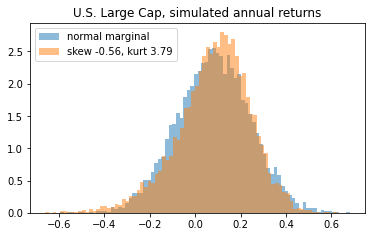

In [13]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(X["U.S. Large Cap"], bins=80, density=True, alpha=0.5, label="normal marginal")
ax.hist(X2["U.S. Large Cap"], bins=80, density=True, alpha=0.5, label="skew -0.56, kurt 3.79")
ax.set_title("U.S. Large Cap, simulated annual returns"); ax.legend(); plt.show()

## Paths

`simulate_paths` returns a `Paths` object of shape `(n_paths, horizon, N)`. With
annual targets, a horizon of 10 means 10 years. Periods are independent here:
the $n_{paths} \times horizon$ period returns are one cross-section drawn by
`simulate` (without the accept-reject step, a small pool cannot meet the
correlation tolerance) and reshaped, so that $r^{(s)}_{i,t}$, $t = 1, \dots, 10$,
are i.i.d. draws from the fitted joint distribution. `terminal` gives the
cumulative return at the end of the horizon,

$$
R^{(s)}_i = \prod_{t=1}^{10} \left(1 + r^{(s)}_{i,t}\right) - 1,
$$

whose distribution across the 2,000 paths is described. Notebook 07 adds
dynamics for daily data.

In [14]:
P = cv2.simulate_paths(n_paths=2000, horizon=10, seed=2)
print(P)
P.terminal().describe().round(3)        # cumulative return after 10 periods

Paths(n_paths=2000, horizon=10, assets=4, returns)


,U.S. Large Cap,U.S. Long Treasuries,Commodities,Gold
count,2000.000,2000.000,2000.000,2000.000
mean,1.196,0.783,0.689,0.705
std,1.084,0.704,0.985,0.930
min,-0.941,-0.700,-1.291,-0.851
25%,0.405,0.281,-0.001,0.060
50%,1.008,0.671,0.500,0.494
75%,1.766,1.162,1.171,1.120
max,6.502,5.220,7.098,7.237


Thirty of the cumulative paths $\prod_{j \le t}(1 + r^{(s)}_{i,j}) - 1$ for
one asset, one line per path, year by year.

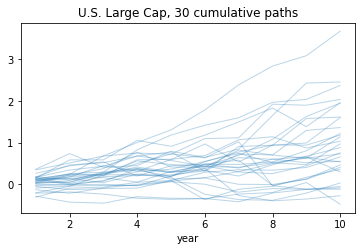

In [15]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(P.cumulative().wide("U.S. Large Cap").iloc[:, :30], color="tab:blue", alpha=0.3, lw=1)
ax.set_title("U.S. Large Cap, 30 cumulative paths"); ax.set_xlabel("year"); plt.show()

## Save and reload

The fitted model is written to JSON: the targets, the Johnson SU parameters,
and for every edge the family, rotation and calibrated parameters. `load`
rebuilds the vine from these numbers, so `simulate` on the reloaded object
draws from the same distribution without refitting; `edges` shows the same
table as before.

In [16]:
cv2.save("my_market.json")
cv3 = CVineMarket.load("my_market.json")
cv3.edges

,tree,edge,selected family,parameters
0,1,"U.S. Long Treasuries , U.S. Large Cap",gaussian 0°,theta=-0.093
1,1,"Commodities , U.S. Large Cap",gaussian 0°,theta=0.459
2,1,"Gold , U.S. Large Cap",gaussian 0°,theta=0.030
3,2,"Commodities , U.S. Long Treasuries | U.S. Larg...",gaussian 0°,theta=-0.205
4,2,"Gold , U.S. Long Treasuries | U.S. Large Cap",gaussian 0°,theta=0.325
5,3,"Gold , Commodities | U.S. Large Cap, U.S. Long...",gaussian 0°,theta=0.494


## Where to next

- `02_bivariate_copulas_and_tails`: the building blocks, one pair at a time.
- `03_fleishman_generator`: the Fleishman generator in detail.
- `04_cvine_step_by_step`: the C-vine pipeline, one algorithm at a time, with a history.
- `05_ltcma_targeting` and `06_macro_factors`: complete workflows.
- `07_daily_paths_for_backtesting`: daily data, GARCH dynamics, paths.